## Peak performance comparison between Multi-core Scan and `torch.clone` copy operator

> The goal is to understand the "peak performance" of Ascend for a simple element-wise operator like `copy` (copy-in and copy-out). We can use this benchmark as the practical peak performance of Ascend.

In [37]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_context('paper', font_scale=2., rc={"lines.linewidth": 1.75} )
sns.set_style({'font.weight': 'bold'})

# Markers
plt.rcParams['lines.markersize'] = 6.5
plt.rcParams['lines.linewidth'] = 1.75
plt.rcParams['figure.figsize'] = (8.7,6.27)

_LEGEND_MARKER_SCALE = 1.75
_MARKERS = ["o", "^", "s", "X"]

_SNS_PARAMS = {"hue":'S', "style":'S', "markers":_MARKERS, "dashes":True}


In [38]:
# Select plot parameters

# dtype = "int8"
dtype = "fp16"
tiles = [32, 64, 128]

In [39]:
def add_stats_siso(df, nbytes_out_dtype: int):
    # Input number of bytes per element
    df["in_bytes_per_elem"] = df["dtype"].map({"fp16": 2, "int8": 1})

    df["mem_bytes"] = df["size"] * (df["in_bytes_per_elem"] + nbytes_out_dtype)
    
    df["gelemps"] = (df["size"] / 1e9) / (df["time_us"] / 1e6)
    df["bw_gbps"] = ( df["mem_bytes"] / 1e9) / (df["time_us"] / 1e6)

In [ ]:
PREFIX_PATH = "../../.."

df_copy = pd.read_csv(f"{PREFIX_PATH}/bench_results_copy_{dtype}.csv")
df_copy["S"] = "memcopy (fp16)"
add_stats_siso(df_copy, 2)


df_cast = pd.read_csv(f"{PREFIX_PATH}/bench_results_cast_{dtype}.csv")
df_cast["S"] = "cast (fp16->32)"
add_stats_siso(df_cast, 4)

df_scan = pd.read_csv(f"{PREFIX_PATH}/bench_results_mcscan_128_{dtype}.csv")
df_scan["S"] = f"TCUSCAN (910B4)"
add_stats_siso(df_scan, 4)

df_scan_910B2 = pd.read_csv(f"{PREFIX_PATH}/bench_results_mcscan_910B2_{dtype}.csv")
df_scan_910B2["S"] = f"TCUSCAN (910B2)"
add_stats_siso(df_scan_910B2, 4)

df_scan_gpu = pd.read_csv(f"{PREFIX_PATH}/bench_results_scan_rtx600ada_{dtype}.csv")
df_scan_gpu["S"] = f"RTX600Ada"
add_stats_siso(df_scan_gpu, 4)

df_scan_rtx400 = pd.read_csv(f"{PREFIX_PATH}/bench_results_scan_rtx400ada_{dtype}.csv")
df_scan_rtx400["S"] = f"RTX400Ada"
add_stats_siso(df_scan_rtx400, 4)

df_scan_l40sx = pd.read_csv(f"{PREFIX_PATH}/bench_results_scan_l40sx_{dtype}.csv")
df_scan_l40sx["S"] = f"L40SX"
add_stats_siso(df_scan_l40sx, 4)

df_scan_a100 = pd.read_csv(f"{PREFIX_PATH}/bench_results_scan_A100_{dtype}.csv")
df_scan_a100["S"] = f"A100"
add_stats_siso(df_scan_a100, 4)

# df = pd.concat([df_copy, df_cast, df_scan, df_scan_gpu, df_scan_rtx400, df_scan_l40sx])
df = pd.concat([df_scan, df_scan_910B2, df_scan_gpu, df_scan_rtx400, df_scan_l40sx, df_scan_a100])

## Paper plots

/tmp/ipykernel_8791/3252844429.py:1: UserWarning: 
The markers list has fewer values (4) than needed (5) and will cycle, which may produce an uninterpretable plot.
  ax = sns.lineplot(data=df, x='size', y='gelemps', **_SNS_PARAMS)


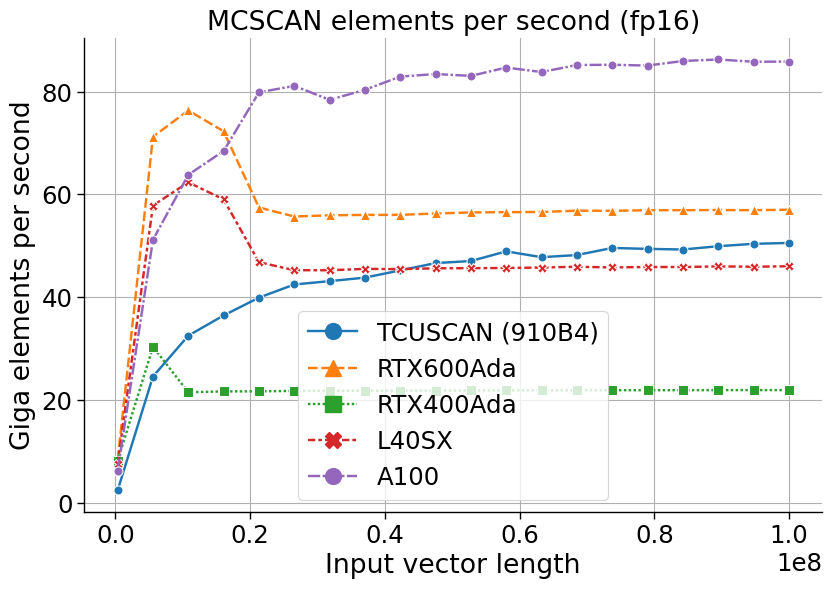

<Figure size 870x627 with 0 Axes>

In [41]:
ax = sns.lineplot(data=df, x='size', y='gelemps', **_SNS_PARAMS)

ax.set_title(f"MCSCAN elements per second ({dtype})")
ax.set_xlabel("Input vector length")
ax.set_ylabel("Giga elements per second")
sns.despine(right = True)
plt.legend(markerscale=_LEGEND_MARKER_SCALE)
plt.grid()
plt.tight_layout()

fig = ax.get_figure()
fig.savefig(f"figs/mcscan_gelemsps_{dtype}.png")
plt.show()
plt.clf()

/tmp/ipykernel_8791/111434224.py:1: UserWarning: 
The markers list has fewer values (4) than needed (5) and will cycle, which may produce an uninterpretable plot.
  ax = sns.lineplot(data=df, x='size', y='bw_gbps', **_SNS_PARAMS)


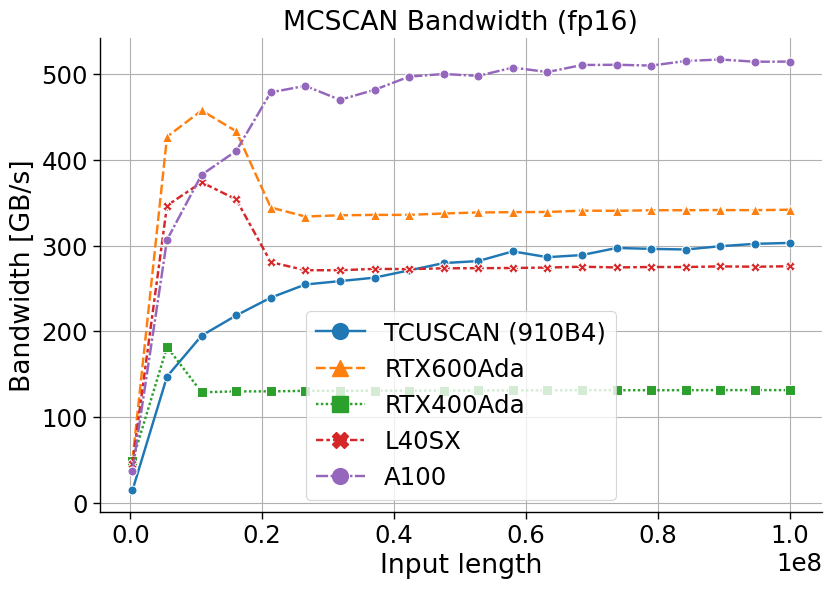

<Figure size 870x627 with 0 Axes>

In [42]:
ax = sns.lineplot(data=df, x='size', y='bw_gbps', **_SNS_PARAMS)

ax.set_title(f"MCSCAN Bandwidth ({dtype})")
ax.set_xlabel("Input length")
ax.set_ylabel("Bandwidth [GB/s]")
sns.despine(right = True)
plt.legend(markerscale=_LEGEND_MARKER_SCALE)
plt.grid()

plt.tight_layout()

fig = ax.get_figure()
fig.savefig(f"figs/mcscan_bw_{dtype}.png")
plt.show()
plt.clf()


In [43]:
df.head(100)

,operator,dtype,size,density,outputsize,time_us,S,in_bytes_per_elem,mem_bytes,gelemps,bw_gbps
0,mcscan_128,fp16,327680,None,327680,135.46,TCUSCAN (910B4),2,1966080,2.419017,14.514100
1,mcscan_128,fp16,5570560,None,5570560,226.74,TCUSCAN (910B4),2,33423360,24.568052,147.408309
2,mcscan_128,fp16,10813440,None,10813440,332.53,TCUSCAN (910B4),2,64880640,32.518690,195.112140
3,mcscan_128,fp16,16056320,None,16056320,440.48,TCUSCAN (910B4),2,96337920,36.451871,218.711224
4,mcscan_128,fp16,21299200,None,21299200,533.56,TCUSCAN (910B4),2,127795200,39.919034,239.514206
...,...,...,...,...,...,...,...,...,...,...,...
15,scan_fp16,fp16,78970880,None,78970880,928.32,A100,2,473825280,85.068597,510.411582
16,scan_fp16,fp16,84213760,None,84213760,979.70,A100,2,505282560,85.958722,515.752332
17,scan_fp16,fp16,89456640,None,89456640,1037.12,A100,2,536739840,86.254860,517.529158
18,scan_fp16,fp16,94699520,None,94699520,1103.54,A100,2,568197120,85.814307,514.885840


In [44]:
max_size = df["size"].max()
df[df["size"] >= 99 * 1e6].head(20)

,operator,dtype,size,density,outputsize,time_us,S,in_bytes_per_elem,mem_bytes,gelemps,bw_gbps
19,mcscan_128,fp16,99942400,None,99942400,1976.68,TCUSCAN (910B4),2,599654400,50.560738,303.364429
19,scan_fp16,fp16,99942400,None,99942400,1752.60,RTX600Ada,2,599654400,57.025220,342.151318
19,scan_fp16,fp16,99942400,None,99942400,4558.51,RTX400Ada,2,599654400,21.924357,131.546141
19,scan_fp16,fp16,99942400,None,99942400,2171.56,L40SX,2,599654400,46.023320,276.139918
19,scan_fp16,fp16,99942400,None,99942400,1164.25,A100,2,599654400,85.842731,515.056388
